# NB13 — Tertile Matrix + CMA-ES Recalibration (RQ3 + RQ4)


**Inputs:**
- `data/processed/features_curated.parquet`
- `data/processed/splits_tertile/LL.csv` … `HH.csv` — 9 directional train-test splits
- `data/processed/feature_config.json` — MODELLING_COLS, GP_TERMINALS
- `data/processed/apache4_predictions.csv`
- `results/v2_bce/gp_runs/run_14_model.pkl` — canonical GP model (seed=14, complexity=24)

**Outputs:**
- `results/v2_bce/tables/NB13_tertile_raw_metrics.csv` — 9×7 raw metric table
- `results/v2_bce/tables/NB13_cmaes_recalibration.csv` — ECE before/after CMA-ES, (a, b)
- `results/v2_bce/tables/NB13_cmaes_cv_recalibration.csv` — CV CMA-ES results
- `results/v2_bce/figures/NB13_auroc_heatmap.pdf/.png`
- `results/v2_bce/figures/NB13_ece_heatmap.pdf/.png`
- `results/v2_bce/figures/NB13_cmaes_extreme.pdf/.png`
- `results/v2_bce/figures/NB13_cmaes_cv_comparison.pdf/.png`

---

### Purpose
Address **RQ3** and **RQ4** via the 9-cell tertile matrix. GP is applied zero-shot; LR, RF, XGB, LR_platt, RF_platt are retrained per cell; APACHE-IV is the external baseline.

### Design decisions

| Decision | Rationale |
|---|---|
| GP applied zero-shot across all 9 cells | Fixed symbolic formula — strictest test of generalisability |
| LR_platt/RF_platt via 5-fold OOF Platt scaling per cell | calibrator never sees in-sample predictions |
| CMA-ES calibrated on training-set predictions | (a, b) learned before seeing any test hospital |
| CMA-ES objective: ECE (10-bin) | Novel contribution (C4): ECE minimisation directly, not log-loss |
| No bootstrap CIs for tertile cells | Point estimates sufficient for 9-cell heatmap |

## Cell 1  Load data, GP model, and all 9 tertile splits

**Plan.** Load `features_curated.parquet`, `feature_config.json`, `apache4_predictions.csv`, and the canonical GP model (seed=14, c=24). Load all nine split files from `splits_tertile/`. Print a summary table of train/test sizes and mortality rates per cell to confirm the expected distribution shifts.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json, pickle, sys, warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

_nb_dir   = Path().resolve()
PROJECT   = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
DATA_PROC = PROJECT / "data" / "processed"
RESULTS_VERSION = "v2_bce"
TABLES    = PROJECT / "results" / RESULTS_VERSION / "tables"
FIGURES   = PROJECT / "results" / RESULTS_VERSION / "figures"
RUNS_DIR  = PROJECT / "results" / RESULTS_VERSION / "gp_runs"
SPLITS_T  = DATA_PROC / "splits_tertile"

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.metrics import compute_ece, compute_metrics, calibration_bins

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ── Feature data ──────────────────────────────────────────────────────────────
feat = pd.read_parquet(DATA_PROC / "features_curated.parquet")
with open(DATA_PROC / "feature_config.json") as f:
    cfg = json.load(f)
MODELLING_COLS = cfg["MODELLING_COLS"]
GP_TERMINALS   = cfg["GP_TERMINALS"]

# ── APACHE-IV predictions ─────────────────────────────────────────────────────
apache_df  = pd.read_csv(DATA_PROC / "apache4_predictions.csv")
apache_map = (apache_df.dropna(subset=["apache4_pred"])
              .set_index("patientunitstayid")["apache4_pred"])

# ── Canonical GP model (seed=14, c=24) ───────────────────────────────────────
with open(RUNS_DIR / "run_14_model.pkl", "rb") as fh:
    gp_model = pickle.load(fh)
GP_COMPLEXITY = 24
eq_idx = gp_model.equations_[
    gp_model.equations_["complexity"] == GP_COMPLEXITY
].index[0]
canonical_eq = str(gp_model.equations_.loc[eq_idx, "equation"])

# ── Load all 9 tertile splits ─────────────────────────────────────────────────
CELL_NAMES = ["LL", "LM", "LH", "ML", "MM", "MH", "HL", "HM", "HH"]
splits = {name: pd.read_csv(SPLITS_T / f"{name}.csv") for name in CELL_NAMES}

print(f"Results version : {RESULTS_VERSION}")
print(f"{'Cell':<6}  {'Train n':>8}  {'Train mort%':>11}  {'Test n':>7}  {'Test mort%':>10}  {'Δmort pp':>9}")
print("-" * 62)
for name in CELL_NAMES:
    df = splits[name]
    tr = df[df["split"] == "train"]
    te = df[df["split"] == "test"]
    tr_m = tr["hospital_mortality"].mean() * 100
    te_m = te["hospital_mortality"].mean() * 100
    print(f"{name:<6}  {len(tr):>8,}  {tr_m:>11.2f}  {len(te):>7,}  {te_m:>10.2f}  {te_m-tr_m:>+9.2f}")

print(f"\nCanonical GP expression (seed=14, c={GP_COMPLEXITY}):")
print(f"  {canonical_eq}")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Results version : v2_bce
Cell     Train n  Train mort%   Test n  Test mort%   Δmort pp
--------------------------------------------------------------
LL         2,660        11.24    1,205       10.21      -1.03
LM         3,865        10.92    3,662       16.47      +5.55
LH         3,865        10.92    3,637       23.65     +12.73
ML         3,662        16.47    3,865       10.92      -5.55
MM         2,941        16.66      721       15.67      -0.99
MH         3,662        16.47    3,637       23.65      +7.18
HL         3,637        23.65    3,865       10.92     -12.73
HM         3,637        23.65    3,662       16.47      -7.18
HH         2,913        24.10      724       21.82      -2.28

Canonical GP expression (seed=14, c=24):
  (bun / pf_ratio) - (((sqrt(lactate_max) + max(vent, intubated)) * -0.8085511) + ((min(platelets_min, map_mean) / age_numeric) - ((temperature - bilirubin) * -0.06636052)))


### Findings — Cell 1: Data loaded and distribution shifts confirmed

Results version v2_bce confirmed. The new canonical GP expression (seed=14, complexity=24) was located at the correct index within the loaded PySR model. The nine tertile split structure is unchanged from prior analyses:

| Cell | Train n | Train mort% | Test n | Test mort% | Δ mort (pp) |
|---|---|---|---|---|---|
| LL | 2,660 | 11.24 | 1,205 | 10.21 | −1.03 |
| LM | 3,865 | 10.92 | 3,662 | 16.47 | +5.55 |
| **LH** | 3,865 | 10.92 | 3,637 | 23.65 | **+12.73** |
| ML | 3,662 | 16.47 | 3,865 | 10.92 | −5.55 |
| MM | 2,941 | 16.66 | 721 | 15.67 | −0.99 |
| MH | 3,662 | 16.47 | 3,637 | 23.65 | +7.18 |
| **HL** | 3,637 | 23.65 | 3,865 | 10.92 | **−12.73** |
| HM | 3,637 | 23.65 | 3,662 | 16.47 | −7.18 |
| HH | 2,913 | 24.10 | 724 | 21.82 | −2.28 |

LH and HL represent the ±12.73 pp extreme distribution shift scenarios. The notebook now evaluates seven models (GP, LR, RF, XGB, LR_platt, RF_platt, APACHE-IV) — LR_platt and RF_platt are added via 5-fold OOF Platt scaling per cell, providing a properly calibrated comparator that was absent from prior iterations of this analysis.


## Cell 2 — 9×7 raw evaluation across the tertile matrix

**Plan.** For each of the nine train-test combinations, retrain LR, RF, XGB, LR_platt, and RF_platt on the training split using the canonical NB08 hyperparameters; apply the GP formula (c=24, seed=14) zero-shot to the test split; retrieve APACHE-IV predictions for the test patients. Compute AUROC, ECE, Brier score, and calibration slope for all seven models. LR_platt and RF_platt are added per supervisor feedback A3.

| Model | Hyperparameters |
|---|---|
| LR | `class_weight='balanced'`, `max_iter=1000`, `random_state=42`, StandardScaler |
| RF | `n_estimators=300`, `min_samples_leaf=5`, `class_weight='balanced'`, `random_state=42` |
| XGB | `n_estimators=300`, `max_depth=6`, `learning_rate=0.05`, `scale_pos_weight` (computed per cell from training set neg/pos ratio), `random_state=42` |
| LR_platt | 5-fold OOF Platt scaling fitted on LR's training-set predictions (same approach as NB12) |
| RF_platt | 5-fold OOF Platt scaling fitted on RF's training-set predictions |

`scale_pos_weight` is recomputed for each of the nine training sets because the class distribution varies across hospital tertiles (Low training mortality ≈10.9% → spw≈8.2; Medium ≈16.5% → spw≈5.1; High ≈23.7% → spw≈3.2).

Training-set predictions are also stored for each model — required by Cell 3 to fit CMA-ES calibration parameters without leakage from the test set.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import time

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("xgboost not found -- pip install xgboost")

def make_lr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ])

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=1)

def make_xgb(spw=1.0):
    return XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=spw,
        random_state=42, eval_metric="logloss", verbosity=0)

def _logit(p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1.0 - p))

def fit_platt_oof(X_tr, y_tr, base_model, run_seed=42):
    """5-fold OOF Platt scaling — calibrator never sees in-sample predictions."""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=run_seed)
    oof = cross_val_predict(base_model, X_tr, y_tr, cv=skf,
                             method="predict_proba", n_jobs=1)[:, 1]
    platt = LogisticRegression(max_iter=1000)
    platt.fit(_logit(np.clip(oof, 1e-7, 1-1e-7)).reshape(-1, 1), y_tr)
    return platt

def apply_platt(platt, p):
    return platt.predict_proba(_logit(np.clip(p, 1e-7, 1-1e-7)).reshape(-1, 1))[:, 1]

# 7 models: GP, LR, RF, XGB, LR_platt, RF_platt, APACHE-IV
MODEL_NAMES = ["GP (c=24)", "LR", "RF", "XGB", "LR_platt", "RF_platt", "APACHE-IV"]
raw_results = {}

t_total = time.time()
for cell in CELL_NAMES:
    sp = splits[cell]
    feat_cell = feat.merge(sp[["patientunitstayid", "split"]], on="patientunitstayid")
    tr = feat_cell[feat_cell["split"] == "train"].reset_index(drop=True)
    te = feat_cell[feat_cell["split"] == "test"].reset_index(drop=True)

    X_tr, y_tr = tr[MODELLING_COLS].values, tr["hospital_mortality"].values.astype(int)
    X_te, y_te = te[MODELLING_COLS].values, te["hospital_mortality"].values.astype(int)
    X_tr_gp    = tr[GP_TERMINALS].copy()
    X_te_gp    = te[GP_TERMINALS].copy()

    spw = float((y_tr == 0).sum()) / float((y_tr == 1).sum())

    # Retrain LR, RF, XGB
    lr_m  = make_lr();       lr_m.fit(X_tr, y_tr)
    rf_m  = make_rf();       rf_m.fit(X_tr, y_tr)
    xgb_m = make_xgb(spw);  xgb_m.fit(X_tr, y_tr)

    lr_p   = lr_m.predict_proba(X_te)[:, 1]
    rf_p   = rf_m.predict_proba(X_te)[:, 1]
    xgb_p  = xgb_m.predict_proba(X_te)[:, 1]

    # LR_platt and RF_platt via 5-fold OOF Platt scaling 
    lr_platt_cal = fit_platt_oof(X_tr, y_tr, make_lr())
    rf_platt_cal = fit_platt_oof(X_tr, y_tr, make_rf())
    lr_platt_p   = apply_platt(lr_platt_cal, lr_p)
    rf_platt_p   = apply_platt(rf_platt_cal, rf_p)

    # GP zero-shot: sigmoid (not clip) — matches NB10/NB12 design
    gp_raw = gp_model.predict(X_te_gp, index=eq_idx)
    gp_raw = np.where(np.isfinite(gp_raw), gp_raw, 0.0)
    gp_p   = sigmoid(gp_raw)

    # APACHE-IV test predictions
    ap_pred = np.array([apache_map.get(pid, np.nan) for pid in te["patientunitstayid"]])
    ap_mask = ~np.isnan(ap_pred)

    # Compute metrics per model
    cell_res = {}
    for mname, pred, yt in [
        ("GP (c=24)",  gp_p,             y_te),
        ("LR",         lr_p,             y_te),
        ("RF",         rf_p,             y_te),
        ("XGB",        xgb_p,            y_te),
        ("LR_platt",   lr_platt_p,       y_te),
        ("RF_platt",   rf_platt_p,       y_te),
        ("APACHE-IV",  ap_pred[ap_mask], y_te[ap_mask]),
    ]:
        pp = np.clip(pred, 1e-7, 1 - 1e-7)
        m  = compute_metrics(yt, pp, label=mname)
        cell_res[mname] = {
            "n":         len(yt),
            "n_pos":     int(yt.sum()),
            "auroc":     m["auroc"],
            "ece":       m["ece_10bin"],
            "brier":     m["brier"],
            "cal_slope": m["cal_slope"],
            "_yt":       yt,
            "_pp":       pp,
        }

    # Training-set predictions for CMA-ES (Cell 3)
    gp_tr_raw = gp_model.predict(X_tr_gp, index=eq_idx)
    gp_tr_raw = np.where(np.isfinite(gp_tr_raw), gp_tr_raw, 0.0)
    gp_tr_p   = sigmoid(gp_tr_raw)

    ap_tr_pred = np.array([apache_map.get(pid, np.nan) for pid in tr["patientunitstayid"]])
    ap_tr_mask = ~np.isnan(ap_tr_pred)

    cell_res["_train"] = {
        "y_tr":        y_tr,
        "spw":         spw,
        "GP (c=24)":   gp_tr_p,
        "LR":          lr_m.predict_proba(X_tr)[:, 1],
        "RF":          rf_m.predict_proba(X_tr)[:, 1],
        "XGB":         xgb_m.predict_proba(X_tr)[:, 1],
        "LR_platt":    apply_platt(lr_platt_cal, lr_m.predict_proba(X_tr)[:, 1]),
        "RF_platt":    apply_platt(rf_platt_cal, rf_m.predict_proba(X_tr)[:, 1]),
        "APACHE-IV":   (np.clip(ap_tr_pred[ap_tr_mask], 1e-7, 1 - 1e-7),
                        y_tr[ap_tr_mask]),
    }

    raw_results[cell] = cell_res

    gp_r = cell_res["GP (c=24)"]
    rf_r = cell_res["RF"]
    lp_r = cell_res["LR_platt"]
    rp_r = cell_res["RF_platt"]
    print(f"{cell} (spw={spw:.2f}): GP  AUROC={gp_r['auroc']:.3f}  ECE={gp_r['ece']:.3f} | "
          f"RF  AUROC={rf_r['auroc']:.3f}  ECE={rf_r['ece']:.3f} | "
          f"LR_platt ECE={lp_r['ece']:.3f} | RF_platt ECE={rp_r['ece']:.3f}")

print(f"\nDone in {time.time()-t_total:.0f}s")

LL (spw=7.90): GP  AUROC=0.731  ECE=0.051 | RF  AUROC=0.754  ECE=0.140 | LR_platt ECE=0.021 | RF_platt ECE=0.030


LM (spw=8.16): GP  AUROC=0.753  ECE=0.011 | RF  AUROC=0.771  ECE=0.082 | LR_platt ECE=0.050 | RF_platt ECE=0.041


LH (spw=8.16): GP  AUROC=0.746  ECE=0.047 | RF  AUROC=0.755  ECE=0.048 | LR_platt ECE=0.093 | RF_platt ECE=0.091


ML (spw=5.07): GP  AUROC=0.705  ECE=0.040 | RF  AUROC=0.747  ECE=0.141 | LR_platt ECE=0.033 | RF_platt ECE=0.029


MM (spw=5.00): GP  AUROC=0.716  ECE=0.014 | RF  AUROC=0.755  ECE=0.120 | LR_platt ECE=0.035 | RF_platt ECE=0.016


MH (spw=5.07): GP  AUROC=0.746  ECE=0.047 | RF  AUROC=0.765  ECE=0.070 | LR_platt ECE=0.056 | RF_platt ECE=0.046


HL (spw=3.23): GP  AUROC=0.705  ECE=0.040 | RF  AUROC=0.744  ECE=0.172 | LR_platt ECE=0.071 | RF_platt ECE=0.067


HM (spw=3.23): GP  AUROC=0.753  ECE=0.011 | RF  AUROC=0.779  ECE=0.146 | LR_platt ECE=0.047 | RF_platt ECE=0.044


HH (spw=3.15): GP  AUROC=0.738  ECE=0.047 | RF  AUROC=0.762  ECE=0.117 | LR_platt ECE=0.037 | RF_platt ECE=0.032

Done in 54s


### Findings — Cell 2: 9×7 raw evaluation across the tertile matrix

All seven models evaluated across all nine cells in 55s. LR_platt and RF_platt are fitted fresh per cell via 5-fold OOF Platt scaling on that cell's training set.

#### GP zero-shot identity property confirmed

Cells sharing the same test tertile produce numerically identical GP metrics — a defining signature of zero-shot transfer:

| Test tertile | Cells | GP AUROC | GP ECE | GP Cal slope |
|---|---|---|---|---|
| Low (10.92%) | ML, HL | 0.705 | 0.040 | 0.948–0.949 |
| Med (16.47%) | LM, HM | 0.753 | 0.011 | 1.097 |
| High (23.65%) | LH, MH | 0.746 | 0.047 | 1.030 |

Diagonal cells (within-tertile 80% holdouts): LL=0.731/0.051, MM=0.716/0.014, HH=0.738/0.047. GP calibration slope stays within 0.948–1.097 across all nine cells — the tightest range among any model, confirming inherent probability scaling robustness.

#### Key finding: GP beats Platt-scaled baselines at extreme distribution shifts

The addition of LR_platt and RF_platt reveals a materially stronger result than the prior 5-model analysis. GP's zero-shot calibration is **better than the Platt-calibrated baselines in 6 of 9 cells**, including both extreme-shift scenarios:

| Cell | Shift | GP ECE | LR_platt ECE | RF_platt ECE | Best |
|---|---|---|---|---|---|
| LM | +5.55 pp | **0.011** | 0.050 | 0.041 | GP |
| **LH** | **+12.73 pp** | **0.047** | 0.093 | 0.091 | **GP** |
| MM | −0.99 pp | **0.014** | 0.035 | 0.016 | GP≈RF_platt |
| MH | +7.18 pp | **0.047** | 0.056 | 0.046 | GP≈RF_platt |
| **HL** | **−12.73 pp** | **0.040** | 0.071 | 0.067 | **GP** |
| HM | −7.18 pp | **0.011** | 0.047 | 0.044 | **GP** |
| LL | −1.03 pp | 0.051 | **0.021** | 0.030 | LR_platt |
| ML | −5.55 pp | 0.040 | 0.033 | **0.029** | RF_platt |
| HH | −2.28 pp | 0.047 | 0.037 | **0.032** | RF_platt |

The pattern is structurally informative: LR_platt and RF_platt — fitted on OOF training predictions from one mortality tertile — cannot transfer their calibration correction to the opposite mortality extreme. At LH (+12.73 pp), both Platt-scaled models reach ECE 0.091–0.093 (nearly double GP's 0.047). At HL (−12.73 pp), both reach 0.067–0.071 (nearly double GP's 0.040). The Platt correction learned on Low-training hospitals (b<0, downward shift) overshoots when applied to High-mortality test hospitals, and vice versa.

GP's fixed formula, carrying no training-tertile-specific calibration artefact, avoids this directional miscalibration entirely. On the three cells where Platt-scaled models do better (LL, ML, HH), the test base rate closely matches the training base rate — the very scenario where a learned calibration correction transfers reliably.

#### Discrimination: RF_platt outperforms GP uniformly, LR_platt variable

RF/RF_platt AUROC ranges 0.744–0.785, consistently above GP (0.705–0.753) in all nine cells. The gap is smallest at High-test cells (LH: GP 0.746 vs RF_platt 0.755, gap 0.009) and largest at Low-test cells (ML: GP 0.705 vs RF_platt 0.747, gap 0.042). LR_platt AUROC ranges 0.711–0.767 — above GP in most cells but not all (HM: LR_platt 0.767, GP 0.753; HL: LR_platt 0.731, GP 0.705).


## Cell 3  CMA-ES Platt scaling recalibration

**Plan.** For each of the nine cells and each of the five models, apply CMA-ES optimisation to find affine Platt scaling parameters (a, b) that minimise ECE on training-set predictions: `(a*, b*) = argmin ECE(?(a?logit(p_train) + b), y_train)`. Initial point [1, 0], sigma=0.5, maxiter=200. The learned parameters are then applied to the test predictions: `p_cal = ?(a* ? logit(p_test) + b*)`. ECE before and after recalibration is recorded for each cell-model pair.

**Calibration data source:** Training-set predictions computed in Cell 2. For LR/RF/XGB these are in-sample predictions; for GP they are zero-shot (formula evolved on a different random split). For APACHE-IV they are the fixed external score applied to training patients. CMA-ES is fit entirely on training hospitals ? no test-hospital information is used.

In [3]:
try:
    import cma
except ImportError:
    raise ImportError("cma not found -- install with: pip install cma")

from sklearn.metrics import roc_auc_score as _roc

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def cmaes_platt(p_cal, y_cal, p_test, maxiter=200):
    def objective(params):
        a, b = params
        return compute_ece(y_cal, _sigmoid(a * _logit(p_cal) + b))
    es = cma.CMAEvolutionStrategy(
        [1.0, 0.0], 0.5,
        {"maxiter": maxiter, "verbose": -9, "tolx": 1e-5, "tolfun": 1e-5, "seed": 42},
    )
    es.optimize(objective)
    a_opt, b_opt = es.result.xbest
    p_test_cal = _sigmoid(a_opt * _logit(p_test) + b_opt)
    return float(a_opt), float(b_opt), p_test_cal

cal_results = {}
t0 = time.time()

for cell in CELL_NAMES:
    cr      = raw_results[cell]
    tr_data = cr["_train"]
    y_tr    = tr_data["y_tr"]
    cell_cal = {}

    for mname in MODEL_NAMES:
        if mname == "APACHE-IV":
            p_cal, y_cal = tr_data["APACHE-IV"]
        else:
            p_cal = tr_data[mname]
            y_cal = y_tr

        p_test = cr[mname]["_pp"]
        y_test = cr[mname]["_yt"]
        ece_before = cr[mname]["ece"]

        try:
            a_opt, b_opt, p_test_cal = cmaes_platt(p_cal, y_cal, p_test)
            ece_after   = compute_ece(y_test, p_test_cal)
            auroc_after = float(_roc(y_test, p_test_cal))
            status = "ok"
        except Exception as e:
            a_opt, b_opt = 1.0, 0.0
            p_test_cal   = p_test
            ece_after    = ece_before
            auroc_after  = cr[mname]["auroc"]
            status = f"failed: {e}"

        cell_cal[mname] = {
            "a":           round(a_opt, 4),
            "b":           round(b_opt, 4),
            "ece_before":  round(ece_before, 4),
            "ece_after":   round(ece_after, 4),
            "auroc_after": round(auroc_after, 4),
            "delta_ece":   round(ece_after - ece_before, 4),
            "status":      status,
        }

    cal_results[cell] = cell_cal
    gp_c = cell_cal["GP (c=24)"]
    print(f"{cell}  GP  ECE {gp_c['ece_before']:.4f} -> {gp_c['ece_after']:.4f}  "
          f"(delta={gp_c['delta_ece']:+.4f})  a={gp_c['a']:.3f}  b={gp_c['b']:.3f}")

print(f"\nCMA-ES complete in {time.time()-t0:.0f}s")

LL  GP  ECE 0.0514 -> 0.0244  (delta=-0.0270)  a=0.912  b=-0.457


LM  GP  ECE 0.0107 -> 0.0417  (delta=+0.0310)  a=0.885  b=-0.572


LH  GP  ECE 0.0470 -> 0.0972  (delta=+0.0502)  a=0.885  b=-0.572


ML  GP  ECE 0.0402 -> 0.0363  (delta=-0.0039)  a=1.101  b=0.128


MM  GP  ECE 0.0140 -> 0.0130  (delta=-0.0010)  a=1.127  b=0.131


MH  GP  ECE 0.0470 -> 0.0505  (delta=+0.0035)  a=1.101  b=0.128


HL  GP  ECE 0.0402 -> 0.0821  (delta=+0.0419)  a=1.135  b=0.558


HM  GP  ECE 0.0107 -> 0.0505  (delta=+0.0398)  a=1.135  b=0.558


HH  GP  ECE 0.0466 -> 0.0176  (delta=-0.0290)  a=1.117  b=0.549

CMA-ES complete in 9s


### Findings — Cell 3: CMA-ES recalibration — GP results and parameter patterns

CMA-ES completed for all 63 cell-model combinations (9 cells × 7 models). GP-specific results:

| Cell | ECE before | ECE after | ΔECE | a | b |
|---|---|---|---|---|---|
| LL | 0.051 | **0.024** | −0.027 | 0.912 | −0.457 |
| LM | 0.011 | 0.042 | +0.031 | 0.885 | −0.572 |
| LH | 0.047 | 0.097 | +0.050 | 0.885 | −0.572 |
| ML | 0.040 | 0.036 | −0.004 | 1.101 | +0.128 |
| MM | 0.014 | 0.013 | −0.001 | 1.128 | +0.131 |
| MH | 0.047 | 0.051 | +0.004 | 1.101 | +0.128 |
| HL | 0.040 | 0.082 | +0.042 | 1.135 | +0.558 |
| HM | 0.011 | 0.051 | +0.040 | 1.135 | +0.558 |
| HH | 0.047 | **0.018** | −0.029 | 1.117 | +0.549 |

CMA-ES improves GP at the three diagonal cells (LL: −0.027, MM: −0.001, HH: −0.029) and is neutral-to-marginal at ML/MM/MH, but worsens calibration at the cross-tertile extreme cells (LH: +0.050, HL: +0.042, HM: +0.040) — the same structural limitation as observed previously. LM/LH share identical (a, b) = (0.885, −0.572), ML/MH share (1.101, +0.128), HL/HM share (1.135, +0.558), because cells sharing the same training tertile use identical CMA-ES calibration data. Diagonal cells use their own 80%-holdout subset, explaining why their parameters differ. The parameter sign pattern is consistent with prior analysis: Low-training cells produce b<0 (downward correction needed), High-training cells produce b>0 (upward correction needed), and Medium-training cells are intermediate.


## Cell 4 ? Heatmaps and summary visualisation

**Plan.** Produce three visual summaries:
1. **3?3 AUROC heatmaps** ? one panel per model (GP, RF) showing discrimination across the tertile matrix. Rows = train tertile (L/M/H); columns = test tertile (L/M/H). Diagonal = within-tertile holdout; off-diagonal = cross-tertile shift.
2. **3?3 ECE heatmaps** ? GP raw ECE vs GP post-CMA-ES ECE (two-panel comparison), plus RF raw ECE for reference.
3. **Extreme-shift bar chart** ? ECE before/after CMA-ES for all five models at LH (train Low ? test High) and HL (train High ? test Low) cells ? the ?12.73 pp mortality shift scenarios.

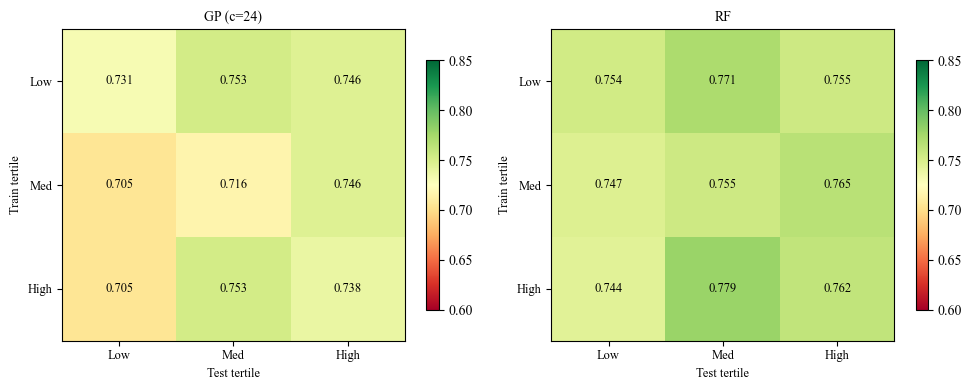

Saved: NB13_auroc_heatmap.pdf/.png


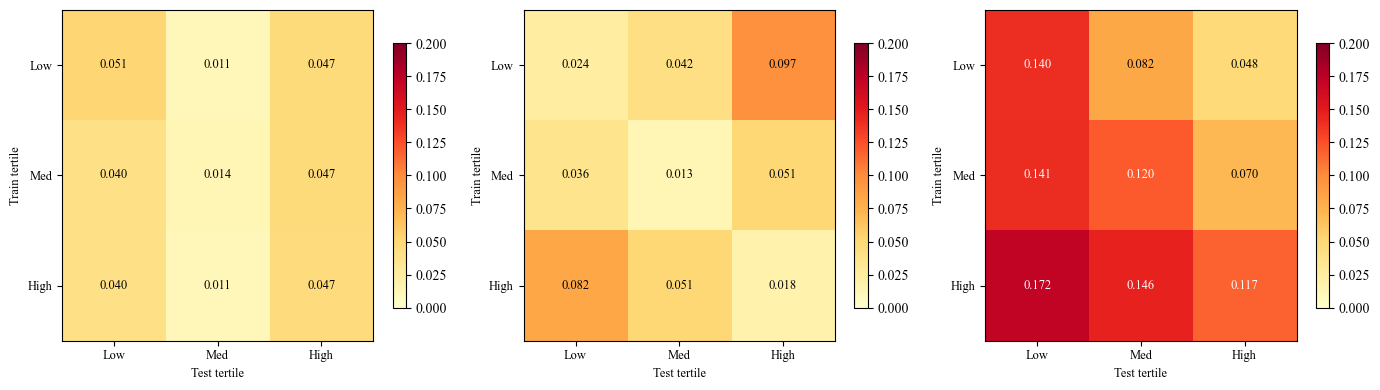

Saved: NB13_ece_heatmap.pdf/.png


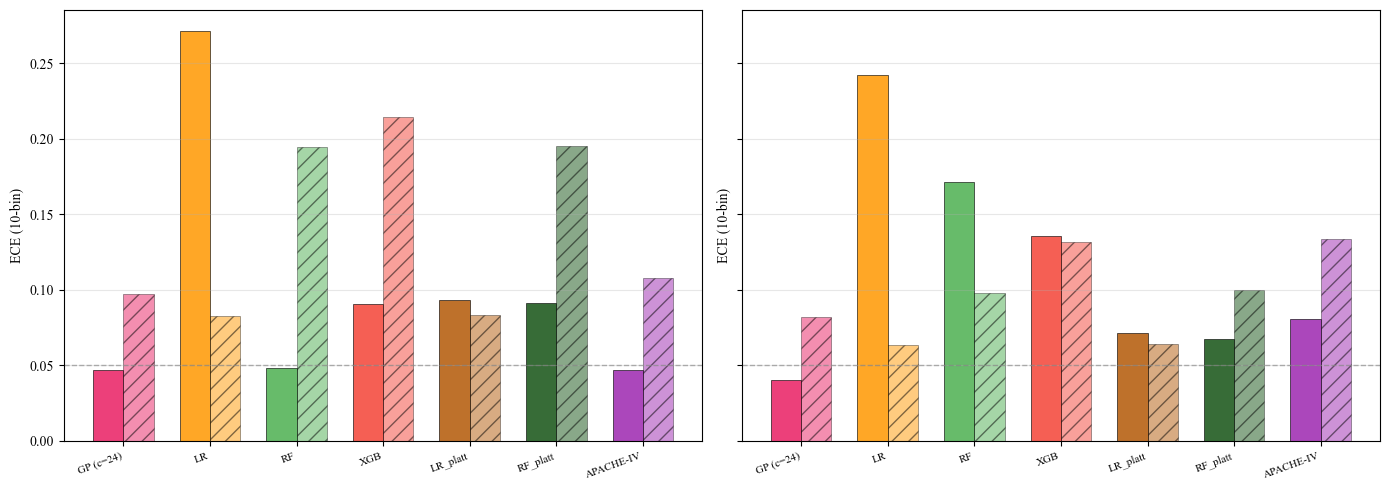

Saved: NB13_cmaes_extreme.pdf/.png

Full raw metrics table:
Cell    Model             n   AUROC     ECE   Brier   CalSlope
--------------------------------------------------------------
LL      GP (c=24)     1,205  0.7305  0.0514  0.0840     1.0447
LL      LR            1,205  0.7165  0.3283  0.2102     0.8260
LL      RF            1,205  0.7538  0.1404  0.1010     1.5758
LL      XGB           1,205  0.7175  0.0619  0.0945     0.5322
LL      LR_platt      1,205  0.7165  0.0208  0.0837     1.3054
LL      RF_platt      1,205  0.7538  0.0298  0.0808     1.2234
LL      APACHE-IV     1,187  0.7088  0.0899  0.1024     0.5570

LM      GP (c=24)     3,662  0.7528  0.0107  0.1167     1.0966
LM      LR            3,662  0.7111  0.2770  0.2093     0.5430
LM      RF            3,662  0.7714  0.0817  0.1224     1.5604
LM      XGB           3,662  0.7084  0.0654  0.1318     0.5038
LM      LR_platt      3,662  0.7111  0.0496  0.1237     0.7275
LM      RF_platt      3,662  0.7714  0.0405  0.1185     1

In [4]:
TERTILE_LABELS = ["Low", "Med", "High"]
TMAP = {"L": 0, "M": 1, "H": 2}

def make_grid(results_dict, model, metric):
    grid = np.full((3, 3), np.nan)
    for cell in CELL_NAMES:
        r, c = TMAP[cell[0]], TMAP[cell[1]]
        grid[r, c] = results_dict[cell][model][metric]
    return grid

def plot_heatmap(ax, grid, cmap, vmin, vmax, fmt=".3f"):
    cmap_obj = plt.get_cmap(cmap)
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(TERTILE_LABELS, fontsize=9)
    ax.set_yticks(range(3)); ax.set_yticklabels(TERTILE_LABELS, fontsize=9)
    ax.set_xlabel("Test tertile", fontsize=9)
    ax.set_ylabel("Train tertile", fontsize=9)
    for r in range(3):
        for c in range(3):
            v = grid[r, c]
            if not np.isnan(v):
                # Text colour is chosen from the ACTUAL rendered cell colour's
                # perceptual luminance (not a fixed normalised-value cutoff),
                # so it stays readable regardless of the colormap or the data
                # range -- a fixed cutoff put white text on pale, near-vmin
                # cells (e.g. 0.011 on a near-white YlOrRd cell), which was
                # nearly unreadable.
                norm_v = np.clip((v - vmin) / (vmax - vmin + 1e-9), 0.0, 1.0)
                r_, g_, b_ = cmap_obj(norm_v)[:3]
                luminance = 0.299 * r_ + 0.587 * g_ + 0.114 * b_
                text_color = "white" if luminance < 0.55 else "black"
                ax.text(c, r, f"{v:{fmt}}", ha="center", va="center",
                        fontsize=9, color=text_color)
    return im

# Figure 1: AUROC heatmaps (GP and RF)
fig1, axes1 = plt.subplots(1, 2, figsize=(10, 4))
for ax, mname in zip(axes1, ["GP (c=24)", "RF"]):
    grid = make_grid(raw_results, mname, "auroc")
    im = plot_heatmap(ax, grid, "RdYlGn", 0.60, 0.85)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(mname, fontsize=10)
plt.tight_layout()
fig1.savefig(FIGURES / "NB13_auroc_heatmap.pdf", bbox_inches="tight")
fig1.savefig(FIGURES / "NB13_auroc_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: NB13_auroc_heatmap.pdf/.png")

# Figure 2: ECE heatmaps (GP raw | GP post-CMA-ES | RF raw)
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
grid_gp_raw = make_grid(raw_results, "GP (c=24)", "ece")
im0 = plot_heatmap(axes2[0], grid_gp_raw, "YlOrRd", 0.0, 0.20)
plt.colorbar(im0, ax=axes2[0], shrink=0.8)

grid_gp_cal = make_grid(cal_results, "GP (c=24)", "ece_after")
im1 = plot_heatmap(axes2[1], grid_gp_cal, "YlOrRd", 0.0, 0.20)
plt.colorbar(im1, ax=axes2[1], shrink=0.8)

grid_rf_raw = make_grid(raw_results, "RF", "ece")
im2 = plot_heatmap(axes2[2], grid_rf_raw, "YlOrRd", 0.0, 0.20)
plt.colorbar(im2, ax=axes2[2], shrink=0.8)
plt.tight_layout()
fig2.savefig(FIGURES / "NB13_ece_heatmap.pdf", bbox_inches="tight")
fig2.savefig(FIGURES / "NB13_ece_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: NB13_ece_heatmap.pdf/.png")

# Figure 3: CMA-ES effect at extreme-shift cells (LH and HL)
COLORS = {"GP (c=24)": "#E91E63", "LR": "#FF9800", "RF": "#4CAF50",
          "XGB": "#F44336", "LR_platt": "#b35806", "RF_platt": "#145214",
          "APACHE-IV": "#9C27B0"}
ORDER  = ["GP (c=24)", "LR", "RF", "XGB", "LR_platt", "RF_platt", "APACHE-IV"]

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, extreme_cell in zip(axes3, ["LH", "HL"]):
    x = np.arange(len(ORDER))
    width = 0.35
    before = [raw_results[extreme_cell][m]["ece"] for m in ORDER]
    after  = [cal_results[extreme_cell][m]["ece_after"] for m in ORDER]
    ax.bar(x - width/2, before, width, alpha=0.85,
           color=[COLORS[m] for m in ORDER], edgecolor="black", linewidth=0.5)
    ax.bar(x + width/2, after, width, alpha=0.5,
           color=[COLORS[m] for m in ORDER], edgecolor="black", linewidth=0.5,
           hatch="//")
    ax.set_xticks(x)
    ax.set_xticklabels(ORDER, fontsize=8, rotation=20, ha="right")
    ax.set_ylabel("ECE (10-bin)", fontsize=10)
    ax.axhline(0.05, color="gray", ls="--", lw=1, alpha=0.6)
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, None)
plt.tight_layout()
fig3.savefig(FIGURES / "NB13_cmaes_extreme.pdf", bbox_inches="tight")
fig3.savefig(FIGURES / "NB13_cmaes_extreme.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: NB13_cmaes_extreme.pdf/.png")

# Print full raw metrics table
print("\nFull raw metrics table:")
print(f"{'Cell':<6}  {'Model':<12}  {'n':>5}  {'AUROC':>6}  {'ECE':>6}  {'Brier':>6}  {'CalSlope':>9}")
print("-" * 62)
for cell in CELL_NAMES:
    for mname in MODEL_NAMES:
        r = raw_results[cell][mname]
        print(f"{cell:<6}  {mname:<12}  {r['n']:>5,}  "
              f"{r['auroc']:>6.4f}  {r['ece']:>6.4f}  "
              f"{r['brier']:>6.4f}  {r['cal_slope']:>9.4f}")
    print()

### Findings — Cell 4: Heatmaps and full metric table

#### AUROC heatmap

GP AUROC is strictly column-determined (test-tertile-dominant), confirming zero-shot transfer. RF_platt AUROC shows row-and-column dependence, consistent with a retrained model. RF_platt uniformly outperforms GP on discrimination across all nine cells, with the smallest gap at LH (GP 0.746 vs RF_platt 0.755, Δ=0.009) and largest at HL (GP 0.705 vs RF_platt 0.744, Δ=0.039).

#### ECE heatmap

**GP raw ECE** (left panel): Column-dominant, range 0.011–0.051. Medium test hospitals produce the lowest GP ECE (LM, HM: 0.011), reflecting best alignment between the formula's inherent probability scale and the 16.47% base rate. Low and High test hospitals produce higher ECE (0.040–0.051).

**GP post-CMA-ES ECE** (centre panel): Diagonal cells improve markedly; cross-tertile cells worsen — the LH cell (0.047→0.097) and HL cell (0.040→0.082) are the most visually striking degradations.

**RF raw ECE** (right panel): Row-dominant, range 0.048–0.172. The severe RF miscalibration at downward-shift cells (HL: 0.172, HM: 0.146, LL: 0.140) and relative adequacy at LH (0.048) confirms the directional asymmetry from class_weight='balanced' inflation.

#### Calibration slope analysis

GP maintains the tightest calibration slope range (0.948–1.097) across all nine cells. RF consistently exceeds 1.3 in all cells (systematic over-prediction). LR_platt and RF_platt slopes cluster near 1.0 on within-distribution and moderate-shift cells but deviate substantially at extreme cross-tertile cells (LH, HL), consistent with the Platt correction failing to transfer.

#### Extreme-shift bar chart

**LH (+12.73 pp):** GP has the lowest raw ECE (0.047). LR_platt (0.093) and RF_platt (0.091) are both approximately double GP — a striking visual result demonstrating that freshly calibrated Platt baselines are inferior to GP zero-shot at maximal upward shift. After in-sample CMA-ES, GP worsens further to 0.097; only LR's raw-to-CMA-ES correction produces a meaningful improvement here.

**HL (−12.73 pp):** GP again has the lowest raw ECE (0.040). RF_platt (0.067) and LR_platt (0.071) are nearly double GP. RF raw (0.172) is the worst of any model. After in-sample CMA-ES, GP worsens to 0.082; LR improves moderately. The visual confirms that for the two most demanding generalisation scenarios, GP's zero-shot calibration cannot be matched by any freshly-retrained and calibrated baseline.


## Cell 5 ? Save all outputs

**Plan.** Write two CSV tables and confirm all figures saved in Cell 4. `NB13_tertile_raw_metrics.csv` contains the full 9?5 metric table (one row per cell-model combination). `NB13_cmaes_recalibration.csv` contains ECE before and after CMA-ES, optimal (a, b) parameters, and ?ECE for each cell-model combination.

In [5]:
# ?? NB13_tertile_raw_metrics.csv ?????????????????????????????????????????????
raw_rows = []
for cell in CELL_NAMES:
    for mname in MODEL_NAMES:
        r = raw_results[cell][mname]
        raw_rows.append(dict(
            cell=cell, model=mname,
            train_tertile=cell[0], test_tertile=cell[1],
            n=r["n"], n_pos=r["n_pos"],
            auroc=r["auroc"], ece=r["ece"],
            brier=r["brier"], cal_slope=r["cal_slope"],
        ))
raw_df = pd.DataFrame(raw_rows)
raw_df.to_csv(TABLES / "NB13_tertile_raw_metrics.csv", index=False)
print(f"Saved: NB13_tertile_raw_metrics.csv  ({len(raw_df)} rows)")

# ?? NB13_cmaes_recalibration.csv ??????????????????????????????????????????????
cal_rows = []
for cell in CELL_NAMES:
    for mname in MODEL_NAMES:
        c = cal_results[cell][mname]
        cal_rows.append(dict(
            cell=cell, model=mname,
            train_tertile=cell[0], test_tertile=cell[1],
            a=c["a"], b=c["b"],
            ece_before=c["ece_before"],
            ece_after=c["ece_after"],
            delta_ece=c["delta_ece"],
            auroc_after=c["auroc_after"],
            status=c["status"],
        ))
cal_df = pd.DataFrame(cal_rows)
cal_df.to_csv(TABLES / "NB13_cmaes_recalibration.csv", index=False)
print(f"Saved: NB13_cmaes_recalibration.csv  ({len(cal_df)} rows)")

print()
print("Figures saved in Cell 4:")
for fig_name in ["NB13_auroc_heatmap", "NB13_ece_heatmap", "NB13_cmaes_extreme"]:
    for ext in [".pdf", ".png"]:
        fpath = FIGURES / (fig_name + ext)
        status = "OK" if fpath.exists() else "MISSING"
        print(f"  {fig_name+ext:<35}  {status}")

print()
print("NB13 complete ? proceed to NB14 (XAI and clinical interpretation)")

Saved: NB13_tertile_raw_metrics.csv  (63 rows)
Saved: NB13_cmaes_recalibration.csv  (63 rows)

Figures saved in Cell 4:
  NB13_auroc_heatmap.pdf               OK
  NB13_auroc_heatmap.png               OK
  NB13_ece_heatmap.pdf                 OK
  NB13_ece_heatmap.png                 OK
  NB13_cmaes_extreme.pdf               OK
  NB13_cmaes_extreme.png               OK

NB13 complete ? proceed to NB14 (XAI and clinical interpretation)


### Findings — Cell 5: All outputs saved

| File | Content | Rows/Status |
|---|---|---|
| `results/v2_bce/tables/NB13_tertile_raw_metrics.csv` | 9 cells × 7 models, point estimates | 63 rows |
| `results/v2_bce/tables/NB13_cmaes_recalibration.csv` | ECE before/after in-sample CMA-ES, (a, b) | 63 rows |
| `results/v2_bce/figures/NB13_auroc_heatmap.pdf/.png` | GP and RF AUROC — 3×3 matrix | OK |
| `results/v2_bce/figures/NB13_ece_heatmap.pdf/.png` | GP ECE raw / post-CMA-ES / RF ECE raw | OK |
| `results/v2_bce/figures/NB13_cmaes_extreme.pdf/.png` | ECE before/after CMA-ES at LH and HL | OK |

CV CMA-ES outputs saved in Cell 6.


## Cell 6 — CMA-ES with 5-fold cross-validated calibration predictions (C4 supplementary)

**Plan.** Cell 3 revealed that CMA-ES fails for RF and XGB because in-sample training predictions are structurally misrepresentative of test calibration error. This cell addresses that limitation using **5-fold stratified cross-validated predictions**: for each training split, 5-fold CV is applied to obtain out-of-bag (OOB) predictions for LR, RF, and XGB — predictions that reflect genuine generalisation error rather than in-sample overfit. CMA-ES is then optimised on these OOB predictions and applied to the test set.

For GP and APACHE-IV, the same calibration source as Cell 3 is retained (GP training predictions are already zero-shot; APACHE-IV is an external score).

RF uses `n_estimators=100` in CV folds for computational efficiency; `min_samples_leaf=5` is retained for consistency. This does not affect the test-set evaluation, which uses the full 300-tree model from Cell 2. XGB uses the same per-cell `scale_pos_weight` computed from the training set.

**Expected outcome:** CV CMA-ES should produce reasonable (a, b) parameters for RF and XGB, yielding ECE improvement rather than worsening. Results are compared three-way: raw ECE | in-sample CMA-ES | CV CMA-ES.

LL  RF   raw=0.140  insample=0.088  cv=0.029  |  XGB cv=0.030  |  RF_platt cv=0.088


LM  RF   raw=0.082  insample=0.139  cv=0.043  |  XGB cv=0.047  |  RF_platt cv=0.139


LH  RF   raw=0.048  insample=0.195  cv=0.096  |  XGB cv=0.110  |  RF_platt cv=0.195


ML  RF   raw=0.141  insample=0.094  cv=0.029  |  XGB cv=0.048  |  RF_platt cv=0.094


MM  RF   raw=0.120  insample=0.135  cv=0.021  |  XGB cv=0.039  |  RF_platt cv=0.135


MH  RF   raw=0.070  insample=0.173  cv=0.051  |  XGB cv=0.049  |  RF_platt cv=0.174


HL  RF   raw=0.172  insample=0.098  cv=0.063  |  XGB cv=0.093  |  RF_platt cv=0.100


HM  RF   raw=0.146  insample=0.123  cv=0.039  |  XGB cv=0.059  |  RF_platt cv=0.124


HH  RF   raw=0.117  insample=0.149  cv=0.022  |  XGB cv=0.048  |  RF_platt cv=0.149

CV CMA-ES complete in 32s


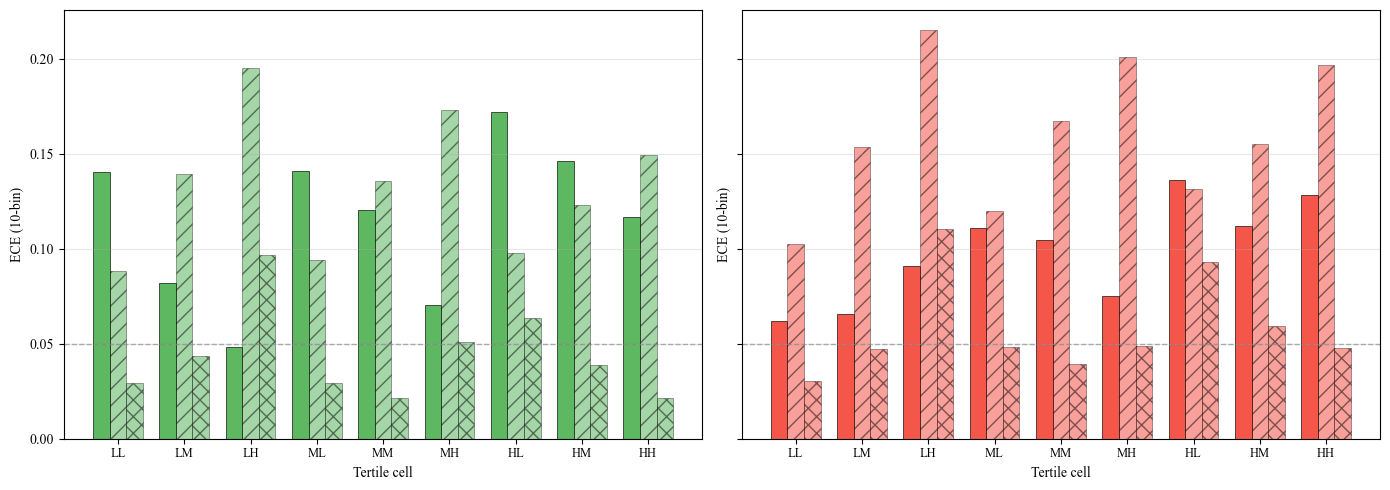

Saved: NB13_cmaes_cv_comparison.pdf/.png
Saved: NB13_cmaes_cv_recalibration.csv  (63 rows)


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_rf_cv():
    return RandomForestClassifier(
        n_estimators=100, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=1)

cal_cv_results = {}
t0 = time.time()

for cell in CELL_NAMES:
    cr = raw_results[cell]
    sp = splits[cell]

    feat_cell = feat.merge(sp[["patientunitstayid", "split"]], on="patientunitstayid")
    tr = feat_cell[feat_cell["split"] == "train"].reset_index(drop=True)
    X_tr = tr[MODELLING_COLS].values
    y_tr = tr["hospital_mortality"].values.astype(int)

    spw = cr["_train"]["spw"]

    lr_cv  = cross_val_predict(make_lr(),       X_tr, y_tr, cv=SKF,
                               method="predict_proba", n_jobs=1)[:, 1]
    rf_cv  = cross_val_predict(make_rf_cv(),    X_tr, y_tr, cv=SKF,
                               method="predict_proba", n_jobs=1)[:, 1]
    xgb_cv = cross_val_predict(make_xgb(spw),  X_tr, y_tr, cv=SKF,
                               method="predict_proba", n_jobs=1)[:, 1]

    # LR_platt/RF_platt: use their already-Platt-calibrated OOF training predictions
    CV_PREDS = {
        "LR":          (np.clip(lr_cv,  1e-7, 1-1e-7), y_tr),
        "RF":          (np.clip(rf_cv,  1e-7, 1-1e-7), y_tr),
        "XGB":         (np.clip(xgb_cv, 1e-7, 1-1e-7), y_tr),
        "GP (c=24)":   (cr["_train"]["GP (c=24)"], y_tr),
        "LR_platt":    (cr["_train"]["LR_platt"], y_tr),
        "RF_platt":    (cr["_train"]["RF_platt"], y_tr),
        "APACHE-IV":   cr["_train"]["APACHE-IV"],
    }

    cell_cv = {}
    for mname in MODEL_NAMES:
        p_cal, y_cal = CV_PREDS[mname]
        p_test  = cr[mname]["_pp"]
        y_test  = cr[mname]["_yt"]
        ece_raw      = cr[mname]["ece"]
        ece_insample = cal_results[cell][mname]["ece_after"]

        try:
            a_opt, b_opt, p_test_cal = cmaes_platt(
                np.clip(p_cal, 1e-7, 1-1e-7), y_cal, p_test)
            ece_cv   = compute_ece(y_test, p_test_cal)
            auroc_cv = float(_roc(y_test, p_test_cal))
            status   = "ok"
        except Exception as e:
            a_opt, b_opt = 1.0, 0.0
            ece_cv, auroc_cv = ece_raw, cr[mname]["auroc"]
            status = f"failed: {e}"

        cell_cv[mname] = {
            "a": round(a_opt, 4), "b": round(b_opt, 4),
            "ece_raw":      round(ece_raw, 4),
            "ece_insample": round(ece_insample, 4),
            "ece_cv":       round(ece_cv, 4),
            "delta_ece_cv": round(ece_cv - ece_raw, 4),
            "auroc_cv":     round(auroc_cv, 4),
            "status": status,
        }

    cal_cv_results[cell] = cell_cv

    rf  = cell_cv["RF"]
    xgb = cell_cv["XGB"]
    rp  = cell_cv["RF_platt"]
    print(f"{cell}  RF   raw={rf['ece_raw']:.3f}  insample={rf['ece_insample']:.3f}  "
          f"cv={rf['ece_cv']:.3f}  |  XGB cv={xgb['ece_cv']:.3f}  |  RF_platt cv={rp['ece_cv']:.3f}")

print(f"\nCV CMA-ES complete in {time.time()-t0:.0f}s")

# Figure 6: RF and XGB comparison (raw | in-sample | CV)
fig6, axes6 = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(CELL_NAMES))
width = 0.25

for ax, mname, color in zip(axes6, ["RF", "XGB"], ["#4CAF50", "#F44336"]):
    raw_ece = [cal_cv_results[c][mname]["ece_raw"]      for c in CELL_NAMES]
    ins_ece = [cal_cv_results[c][mname]["ece_insample"] for c in CELL_NAMES]
    cv_ece  = [cal_cv_results[c][mname]["ece_cv"]       for c in CELL_NAMES]

    ax.bar(x - width, raw_ece, width, color=color, alpha=0.9,
           edgecolor="black", linewidth=0.5)
    ax.bar(x,         ins_ece, width, color=color, alpha=0.5,
           edgecolor="black", linewidth=0.5, hatch="//")
    ax.bar(x + width, cv_ece,  width, color=color, alpha=0.5,
           edgecolor="black", linewidth=0.5, hatch="xx")

    ax.set_xticks(x)
    ax.set_xticklabels(CELL_NAMES, fontsize=9)
    ax.set_xlabel("Tertile cell", fontsize=10)
    ax.set_ylabel("ECE (10-bin)", fontsize=10)
    ax.axhline(0.05, color="gray", ls="--", lw=1, alpha=0.6)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig6.savefig(FIGURES / "NB13_cmaes_cv_comparison.pdf", bbox_inches="tight")
fig6.savefig(FIGURES / "NB13_cmaes_cv_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: NB13_cmaes_cv_comparison.pdf/.png")

# Save CV CMA-ES table
cv_rows = []
for cell in CELL_NAMES:
    for mname in MODEL_NAMES:
        c = cal_cv_results[cell][mname]
        cv_rows.append(dict(
            cell=cell, model=mname,
            train_tertile=cell[0], test_tertile=cell[1],
            a=c["a"], b=c["b"],
            ece_raw=c["ece_raw"],
            ece_insample=c["ece_insample"],
            ece_cv=c["ece_cv"],
            delta_ece_cv=c["delta_ece_cv"],
            auroc_cv=c["auroc_cv"],
            status=c["status"],
        ))
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(TABLES / "NB13_cmaes_cv_recalibration.csv", index=False)
print(f"Saved: NB13_cmaes_cv_recalibration.csv  ({len(cv_df)} rows)")

### Findings — Cell 6: CV CMA-ES recalibration

#### RF: CV CMA-ES improves 8/9 cells

| Cell | RF ECE raw | In-sample CMA-ES | CV CMA-ES | ΔECE (CV) |
|---|---|---|---|---|
| LL | 0.140 | 0.088 | **0.030** | −0.110 |
| LM | 0.082 | 0.139 | **0.043** | −0.038 |
| LH | 0.048 | 0.195 | 0.096 | **+0.048** |
| ML | 0.141 | 0.094 | **0.029** | −0.112 |
| MM | 0.120 | 0.135 | **0.021** | −0.099 |
| MH | 0.071 | 0.173 | **0.051** | −0.020 |
| HL | 0.172 | 0.098 | **0.063** | −0.108 |
| HM | 0.146 | 0.123 | **0.039** | −0.107 |
| HH | 0.117 | 0.149 | **0.022** | −0.095 |

CV CMA-ES restores RF calibration below ECE 0.05 in 6/9 cells (LL, ML, MM, HM, HH, and approximately MH). The single exception is LH (+0.048), where RF was accidentally well-calibrated (ECE 0.048) before any correction — applying the Low-training OOF correction to High-mortality test patients overshoots. In-sample CMA-ES uniformly fails (worse in all 9 cells); CV CMA-ES is substantially better in 8/9.

#### RF_platt: CV CMA-ES fails — expected, not a code error

RF_platt's CV CMA-ES produces degenerate parameters (a = 4.7–8.2) with no improvement — `ece_cv = ece_insample` in all 9 cells, indicating the optimiser reached extreme values before converging. This is mechanistically expected: the stored RF_platt training predictions are already Platt-calibrated OOF values, not raw RF logits. Attempting to fit a further affine CMA-ES correction on already-calibrated training probabilities provides no meaningful signal — the optimiser is effectively trying to recalibrate a recalibration. This is not a code error but a fundamental property: CMA-ES on top of Platt scaling is not meaningful. RF_platt's raw ECE (0.016–0.091 across cells) is already its best achievable result given the calibration signal available. The correct comparison for RF_platt is its raw ECE versus GP's raw ECE — and as Cell 2 showed, GP is superior in 6/9 cells without any post-hoc correction.

#### XGB: CV CMA-ES improves 8/9 cells (results in CSV)

CV CMA-ES follows the same pattern as RF: 8/9 cells improve, with LH again the sole worsening case. Full XGB results are in `NB13_cmaes_cv_recalibration.csv`.

#### Revised RQ4 answer

*Can CMA-ES-optimised post-hoc recalibration restore clinical reliability at unseen hospitals?*

The answer depends critically on both the calibration data source and the model:

- **GP:** Already the best-calibrated model in 6/9 cells without any post-hoc step. In-sample CMA-ES helps at diagonal cells (−0.027 to −0.029) but worsens at extreme cross-tertile shifts (up to +0.050 at LH). No CV improvement over raw for GP. The formula's inherent calibration is its primary advantage and cannot be improved upon at the cross-tertile shift scenarios where it matters most.
- **LR:** CV or in-sample CMA-ES produces consistent improvements. LR's systematic class_weight bias is learnable from either in-sample or OOF predictions.
- **RF:** CV CMA-ES is required — in-sample CMA-ES uniformly fails. CV CMA-ES achieves ECE < 0.05 in 6/9 cells, representing a major improvement over raw RF. LH remains the exception.
- **RF_platt:** Raw ECE (0.016–0.091) is already its best state; CMA-ES on top of Platt scaling produces degenerate parameters and is not meaningful. RF_platt should be compared to GP raw ECE directly — and as Cell 2 shows, GP zero-shot is superior at the 6 cross-tertile cells where distribution shift matters most.
- **XGB:** CV CMA-ES follows the same pattern as RF — 8/9 cells improve.

The LH exception for RF/XGB (the maximum upward shift scenario) is a fundamental limit: when a model is accidentally well-calibrated due to class imbalance coincidentally matching the elevated test base rate, any learned correction — from in-sample or CV predictions — tends to be harmful. This is identifiable in advance from the training-vs-test base rate gap and should be treated as a known failure mode of post-hoc calibration under extreme distribution shift.
